# Web Scraping Project

## Problem Statement
Analyze smartphone prices, ratings, discounts, RAM, storage, and reviews to understand customer preferences and product performance.

# Import Libraries

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')

# Web Scraping Data Collection

In [179]:
url = "https://www.flipkart.com/search?q=smartphones"

In [180]:
response = requests.get(url)
response

<Response [403]>

In [181]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

In [182]:
response = requests.get(url, headers=headers)
response

<Response [200]>

In [183]:
pagecontent  = response.text

In [184]:
print(len(pagecontent))

577529


In [185]:
soup = BeautifulSoup(pagecontent)

In [186]:
pname = soup.find('div', attrs={'class':'RG5Slk'})
pname

<div class="RG5Slk">vivo T5x 5G (Cyber Green, 128 GB)</div>

In [187]:
productname=[]

for x in soup.find_all('div',attrs={'class':"RG5Slk"}):
    productname.append(x.text if x else np.nan)

for name in productname:
    print(name)

vivo T5x 5G (Cyber Green, 128 GB)
realme P4 Power 5G (TransSilver, 128 GB)
Ai+ Pulse 2 (Blue, 64 GB)
MOTOROLA g06 power (Pantone tapestry, 64 GB)
realme P4 Lite 5G (Mosaic Green, 64 GB)
MOTOROLA g35 5G (Leaf Green, 128 GB)
Ai+ Pulse 2 (Purple, 64 GB)
Ai+ Pulse 1 (Sparkle Red, 64 GB)
Ai+ Pulse 1 (Blue, 64 GB)
Ai+ Pulse 1 (Purple, 64 GB)
MOTOROLA g57 power 5G (Pantone Fluidity, 128 GB)
realme P4 Lite 5G (Mosaic Blue, 64 GB)
MOTOROLA g35 5G (Midnight Black, 128 GB)
Samsung M06 5G (Sage Green, 128 GB)
MOTOROLA g06 power (Pantone Tendril, 64 GB)
realme P4 Lite (Sea Blue, 128 GB)
MOTOROLA G96 5G (Pantone Ashleigh Blue, 128 GB)
Ai+ Pulse 1 (Green, 64 GB)
realme P4 Lite 5G (Mosaic Green, 128 GB)
Samsung M06 5G (Sage Green, 128 GB)
vivo T5x 5G (Cyber Green, 128 GB)
vivo T5x 5G (Cyber Green, 256 GB)
POCO M8 (Frost Silver, 128 GB)
MOTOROLA g35 5G (Guava Red, 128 GB)


In [188]:
rating=soup.find("span",attrs={"class":"PvbNMB"})
rating

<span class="PvbNMB"><span><span>5,072 Ratings </span><span class="o2SIOJ">&amp;</span><span> 344 Reviews</span></span></span>

In [189]:
ratings=[]

for x in soup.find_all('span',attrs={'class':"PvbNMB"}):
    ratings.append(x.text if x else np.nan)

for name in ratings:
    print(name)

5,072 Ratings & 344 Reviews
3,759 Ratings & 340 Reviews
1,512 Ratings & 98 Reviews
15,153 Ratings & 894 Reviews
1,715 Ratings & 111 Reviews
1,33,905 Ratings & 8,228 Reviews
1,512 Ratings & 98 Reviews
42,010 Ratings & 2,778 Reviews
42,010 Ratings & 2,778 Reviews
42,010 Ratings & 2,778 Reviews
38,536 Ratings & 2,292 Reviews
1,715 Ratings & 111 Reviews
1,33,905 Ratings & 8,228 Reviews
1,550 Ratings & 94 Reviews
15,153 Ratings & 894 Reviews
1,759 Ratings & 79 Reviews
87,373 Ratings & 4,864 Reviews
42,010 Ratings & 2,778 Reviews
522 Ratings & 42 Reviews
1,218 Ratings & 65 Reviews
5,072 Ratings & 344 Reviews
6,710 Ratings & 562 Reviews
1,049 Ratings & 99 Reviews
1,33,905 Ratings & 8,228 Reviews


In [190]:
spefications=soup.find("div",attrs={'class':'HwRTzP'})
spefications

In [191]:
specifications=[]

for x in soup.find_all('div',attrs={'class':"CMXw7N"}):
    specifications.append(x.text if x else np.nan)

for name in specifications:
    print(name)

6 GB RAM | 128 GB ROM17.17 cm (6.76 inch) Display50MP + 2MP | 32MP Front Camera7200 mAh Li-ion BatteryDimensity 7400-Turbo Processor1 Year Manufacturer Warranty for Device and 6 Months Manufacturer Warranty for Inbox Accessories
8 GB RAM | 128 GB ROM17.27 cm (6.8 inch) Full HD+ AMOLED Display50MP + 8MP | Yes10001 mAh BatteryDimensity 7400 Ultra Processor1 Year Manufacturer Warranty for Device and 6 Months Manufacturer Warranty for Inbox Accessories
4 GB RAM | 64 GB ROM | Expandable Upto 1 TB17.13 cm (6.745 inch) HD+ Display50MP Rear Camera | 8MP Front Camera6000 mAh BatteryT7250 Processor1 Year Warranty on Handset and 6 Months Warranty on the Inbox Accessories
4 GB RAM | 64 GB ROM | Expandable Upto 1 TB17.48 cm (6.88 inch) HD+ Display50MP Rear Camera | 8MP Front Camera7000 mAh BatteryHelio G81 Processor1 Year Warranty on Handset and 6 Months Warranty on Accessories
4 GB RAM | 64 GB ROM17.27 cm (6.8 inches) HD+ Display13MP Rear Camera | 5MP Front Camera7000 mAh lithium-ion polymer Batte

In [192]:
price=soup.find("div",attrs={"class":"kRYCnD gxR4EY"})
price

<div class="kRYCnD gxR4EY">₹<!-- -->28,999</div>

In [193]:
price=[]

for x in soup.find_all('div',attrs={'class':"kRYCnD gxR4EY"}):
    price.append(x.text if x else np.nan)

for name in price:
    print(name)

₹28,999
₹32,999
₹10,999
₹19,999
₹10,999
₹19,999
₹15,499
₹13,999
₹22,999
₹15,497
₹28,999
₹33,999
₹21,999


In [194]:
discount=soup.find("div",attrs={'class':"hZ3P6w DeU9vF"})
discount

<div class="hZ3P6w DeU9vF">₹22,999</div>

In [195]:
discount=[]

for x in soup.find_all('div',attrs={'class':"hZ3P6w DeU9vF"}):
    discount.append(x.text if x else np.nan)

for name in discount:
    print(name)

₹22,999
₹27,999
₹8,999
₹9,999
₹13,499
₹12,499
₹8,999
₹7,999
₹7,999
₹7,999
₹17,999
₹13,499
₹12,499
₹12,288
₹9,999
₹12,999
₹20,999
₹7,999
₹16,499
₹13,830
₹22,999
₹26,999
₹17,999
₹12,499


In [196]:
reviews=soup.find("span",attrs={'class':"PvbNMB"})
reviews

<span class="PvbNMB"><span><span>5,072 Ratings </span><span class="o2SIOJ">&amp;</span><span> 344 Reviews</span></span></span>

In [197]:
reviews=[]

for x in soup.find_all('span',attrs={'class':"PvbNMB"}):
    reviews.append(x.text if x else np.nan)

for name in reviews:
    print(name)

5,072 Ratings & 344 Reviews
3,759 Ratings & 340 Reviews
1,512 Ratings & 98 Reviews
15,153 Ratings & 894 Reviews
1,715 Ratings & 111 Reviews
1,33,905 Ratings & 8,228 Reviews
1,512 Ratings & 98 Reviews
42,010 Ratings & 2,778 Reviews
42,010 Ratings & 2,778 Reviews
42,010 Ratings & 2,778 Reviews
38,536 Ratings & 2,292 Reviews
1,715 Ratings & 111 Reviews
1,33,905 Ratings & 8,228 Reviews
1,550 Ratings & 94 Reviews
15,153 Ratings & 894 Reviews
1,759 Ratings & 79 Reviews
87,373 Ratings & 4,864 Reviews
42,010 Ratings & 2,778 Reviews
522 Ratings & 42 Reviews
1,218 Ratings & 65 Reviews
5,072 Ratings & 344 Reviews
6,710 Ratings & 562 Reviews
1,049 Ratings & 99 Reviews
1,33,905 Ratings & 8,228 Reviews


In [198]:
discount=soup.find("div",attrs={'class':"HQe8jr"})
discount

<div class="HQe8jr"><span>20% off</span></div>

In [199]:
discount=[]

for x in soup.find_all('div',attrs={'class':"HQe8jr"}):
    discount.append(x.text if x else np.nan)

for name in discount:
    print(name)

20% off
15% off
18% off
32% off
18% off
32% off
20% off
7% off
28% off
10% off
20% off
20% off
18% off
20% off
15% off
20% off
20% off


In [200]:
for i in range (1,93):
    print(f"https://www.flipkart.com/search?q=smartphones")

https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=smartphones
https://www.flipkart.com/search?q=

In [207]:
from bs4 import BeautifulSoup
import requests
import numpy as np
import time

# Empty lists
productname = [] 
price = []
rating = []
features = []
pagenum = []
original_price = []
Discount = []
Review = []

# Headers
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0 Safari/537.36"
}

total_time = time.time()

# Page loop
for i in range(1, 106): 
    start_time = time.time()

    # Keep your original Flipkart URL structure + add page number
    URL = f"https://www.flipkart.com/search?q=Mobile&page={i}&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off"

    # Request page
    page = requests.get(URL, headers=headers)

    # Parse page
    soup = BeautifulSoup(page.text, "html.parser")

    # Product container based on your structure
    for x in soup.find_all('div', attrs={'class':'ZFwe0M row'}):
        
        # Product Name
        pname = x.find('div', attrs={'class':'RG5Slk'})
        
        # Current Price
        cost = x.find('div', attrs={'class':'hZ3P6w DeU9vF'})
        
        # Rating
        rat = x.find('div', attrs={'class':'MKiFS6'})
        
        # Features
        specs = x.find('ul', attrs={'class':'HwRTzP'})
        
        # Original Price
        op = x.find('div', attrs={'class':'kRYCnD gxR4EY'})
        
        # Discount
        discount = x.find('div', attrs={'class':'HQe8jr'})
        
        # Reviews
        reviews = x.find('span', attrs={'class':'PvbNMB'})

        # Append values
        productname.append(pname.text.strip() if pname else np.nan)
        price.append(cost.text.strip() if cost else np.nan)
        rating.append(rat.text.strip() if rat else np.nan)
        features.append(specs.get_text(" | ", strip=True) if specs else np.nan)
        original_price.append(op.text.strip() if op else np.nan)
        Discount.append(discount.text.strip() if discount else np.nan)
        Review.append(reviews.text.strip() if reviews else np.nan)

        # Page number
        pagenum.append(i)

    print(f"Page {i} completed in {time.time()-start_time:.2f} seconds")

print("Total Time Completed in seconds:", round(time.time()-total_time, 2))

Page 1 completed in 0.54 seconds
Page 2 completed in 0.45 seconds
Page 3 completed in 0.44 seconds
Page 4 completed in 0.46 seconds
Page 5 completed in 0.57 seconds
Page 6 completed in 0.57 seconds
Page 7 completed in 0.47 seconds
Page 8 completed in 0.58 seconds
Page 9 completed in 0.91 seconds
Page 10 completed in 0.49 seconds
Page 11 completed in 0.68 seconds
Page 12 completed in 1.07 seconds
Page 13 completed in 0.50 seconds
Page 14 completed in 0.46 seconds
Page 15 completed in 0.57 seconds
Page 16 completed in 0.56 seconds
Page 17 completed in 0.62 seconds
Page 18 completed in 0.64 seconds
Page 19 completed in 0.45 seconds
Page 20 completed in 0.62 seconds
Page 21 completed in 0.46 seconds
Page 22 completed in 0.43 seconds
Page 23 completed in 0.43 seconds
Page 24 completed in 0.51 seconds
Page 25 completed in 0.69 seconds
Page 26 completed in 0.45 seconds
Page 27 completed in 0.53 seconds
Page 28 completed in 0.84 seconds
Page 29 completed in 0.73 seconds
Page 30 completed in 0.

# Create DataFrame

In [208]:
df = pd.DataFrame({
    "Product Name": productname,
    "Price": price,
    "Original Price": original_price,
    "Discount": Discount,
    "Rating": rating,
    "Reviews": Review,
    "Features": features,
    "Page Number": pagenum
})


In [209]:
df

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
0,"vivo T5x 5G (Cyber Green, 128 GB)","₹22,999","₹28,999",20% off,4.4,"5,072 Ratings & 344 Reviews",6 GB RAM | 128 GB ROM | 17.17 cm (6.76 inch) D...,1
1,"Ai+ Pulse 2 (Blue, 64 GB)","₹8,999","₹10,999",18% off,4.3,"1,512 Ratings & 98 Reviews",4 GB RAM | 64 GB ROM | Expandable Upto 1 TB | ...,1
2,"IQOO Z11x 5G (Prismatic Green, 128 GB)","₹21,645","₹28,999",25% off,4.4,384 Ratings & 31 Reviews,6 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Di...,1
3,"Ai+ Pulse 2 (Green, 64 GB)","₹8,999","₹10,999",18% off,4.3,"1,512 Ratings & 98 Reviews",4 GB RAM | 64 GB ROM | Expandable Upto 1 TB | ...,1
4,"IQOO Z11x 5G (Titan Black, 128 GB)","₹21,972","₹28,999",24% off,4.4,384 Ratings & 31 Reviews,6 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Di...,1
...,...,...,...,...,...,...,...,...
979,"Samsung Galaxy S24 FE 5G (Blue, 128 GB)","₹39,999","₹59,999",33% off,4.5,"78,184 Ratings & 5,470 Reviews",8 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Fu...,41
980,"Samsung Galaxy S24 FE 5G (Graphite, 256 GB)","₹45,999","₹65,999",30% off,4.5,"78,184 Ratings & 5,470 Reviews",8 GB RAM | 256 GB ROM | 17.02 cm (6.7 inch) Fu...,41
981,"LAVA Play Ultra 5G (Arctic Slate, 128 GB)","₹16,999","₹17,999",5% off,3.5,24 Ratings & 5 Reviews,6 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Di...,41
982,"realme Narzo 80 Pro 5G (Speed Silver, 256 GB)","₹25,800","₹27,999",7% off,4.5,182 Ratings & 20 Reviews,12 GB RAM | 256 GB ROM | 17.2 cm (6.77 inch) D...,41


In [210]:
df.to_csv("Mobile.csv",index=False)

# Importing the Libraries

In [3]:
import numpy as np
import pandas as pd
import json
from pandas import json_normalize
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import re

# Importing the Dataset

In [212]:
df=pd.read_csv("Mobile.csv")
df

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
0,"vivo T5x 5G (Cyber Green, 128 GB)","₹22,999","₹28,999",20% off,4.4,"5,072 Ratings & 344 Reviews",6 GB RAM | 128 GB ROM | 17.17 cm (6.76 inch) D...,1
1,"Ai+ Pulse 2 (Blue, 64 GB)","₹8,999","₹10,999",18% off,4.3,"1,512 Ratings & 98 Reviews",4 GB RAM | 64 GB ROM | Expandable Upto 1 TB | ...,1
2,"IQOO Z11x 5G (Prismatic Green, 128 GB)","₹21,645","₹28,999",25% off,4.4,384 Ratings & 31 Reviews,6 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Di...,1
3,"Ai+ Pulse 2 (Green, 64 GB)","₹8,999","₹10,999",18% off,4.3,"1,512 Ratings & 98 Reviews",4 GB RAM | 64 GB ROM | Expandable Upto 1 TB | ...,1
4,"IQOO Z11x 5G (Titan Black, 128 GB)","₹21,972","₹28,999",24% off,4.4,384 Ratings & 31 Reviews,6 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Di...,1
...,...,...,...,...,...,...,...,...
979,"Samsung Galaxy S24 FE 5G (Blue, 128 GB)","₹39,999","₹59,999",33% off,4.5,"78,184 Ratings & 5,470 Reviews",8 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Fu...,41
980,"Samsung Galaxy S24 FE 5G (Graphite, 256 GB)","₹45,999","₹65,999",30% off,4.5,"78,184 Ratings & 5,470 Reviews",8 GB RAM | 256 GB ROM | 17.02 cm (6.7 inch) Fu...,41
981,"LAVA Play Ultra 5G (Arctic Slate, 128 GB)","₹16,999","₹17,999",5% off,3.5,24 Ratings & 5 Reviews,6 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Di...,41
982,"realme Narzo 80 Pro 5G (Speed Silver, 256 GB)","₹25,800","₹27,999",7% off,4.5,182 Ratings & 20 Reviews,12 GB RAM | 256 GB ROM | 17.2 cm (6.77 inch) D...,41


# Reading the Data Set

In [213]:
df.head()

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
0,"vivo T5x 5G (Cyber Green, 128 GB)","₹22,999","₹28,999",20% off,4.4,"5,072 Ratings & 344 Reviews",6 GB RAM | 128 GB ROM | 17.17 cm (6.76 inch) D...,1
1,"Ai+ Pulse 2 (Blue, 64 GB)","₹8,999","₹10,999",18% off,4.3,"1,512 Ratings & 98 Reviews",4 GB RAM | 64 GB ROM | Expandable Upto 1 TB | ...,1
2,"IQOO Z11x 5G (Prismatic Green, 128 GB)","₹21,645","₹28,999",25% off,4.4,384 Ratings & 31 Reviews,6 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Di...,1
3,"Ai+ Pulse 2 (Green, 64 GB)","₹8,999","₹10,999",18% off,4.3,"1,512 Ratings & 98 Reviews",4 GB RAM | 64 GB ROM | Expandable Upto 1 TB | ...,1
4,"IQOO Z11x 5G (Titan Black, 128 GB)","₹21,972","₹28,999",24% off,4.4,384 Ratings & 31 Reviews,6 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Di...,1


In [214]:
df.tail()

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
979,"Samsung Galaxy S24 FE 5G (Blue, 128 GB)","₹39,999","₹59,999",33% off,4.5,"78,184 Ratings & 5,470 Reviews",8 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Fu...,41
980,"Samsung Galaxy S24 FE 5G (Graphite, 256 GB)","₹45,999","₹65,999",30% off,4.5,"78,184 Ratings & 5,470 Reviews",8 GB RAM | 256 GB ROM | 17.02 cm (6.7 inch) Fu...,41
981,"LAVA Play Ultra 5G (Arctic Slate, 128 GB)","₹16,999","₹17,999",5% off,3.5,24 Ratings & 5 Reviews,6 GB RAM | 128 GB ROM | 17.02 cm (6.7 inch) Di...,41
982,"realme Narzo 80 Pro 5G (Speed Silver, 256 GB)","₹25,800","₹27,999",7% off,4.5,182 Ratings & 20 Reviews,12 GB RAM | 256 GB ROM | 17.2 cm (6.77 inch) D...,41
983,"Samsung Galaxy S24 Exynos 5G (Amber Yellow, 51...","₹61,999","₹89,999",31% off,4.5,"6,845 Ratings & 445 Reviews",8 GB RAM | 512 GB ROM | 15.75 cm (6.2 inch) Fu...,41


# Check the Information from the DataSet

# Shape of the Data

In [216]:
df.shape

(984, 8)

# checking the rows

In [217]:
df.index

RangeIndex(start=0, stop=984, step=1)

# checking the columns

In [218]:
df.columns

Index(['Product Name', 'Price', 'Original Price', 'Discount', 'Rating',
       'Reviews', 'Features', 'Page Number'],
      dtype='object')

# Information of the Data

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product Name    984 non-null    object 
 1   Price           984 non-null    object 
 2   Original Price  886 non-null    object 
 3   Discount        858 non-null    object 
 4   Rating          978 non-null    float64
 5   Reviews         978 non-null    object 
 6   Features        984 non-null    object 
 7   Page Number     984 non-null    int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 61.6+ KB


# Summary Of the Data

In [242]:
df.describe()

,Rating,Page Number,number_of_ratings
count,980.000000,980.000000,980.000000
mean,4.223163,21.024490,144.660204
std,0.291108,11.838607,240.631935
min,3.000000,1.000000,1.000000
25%,4.100000,11.000000,3.000000
50%,4.300000,21.000000,18.000000
75%,4.400000,31.000000,168.250000
max,5.000000,41.000000,986.000000


In [220]:
df.describe(include = 'all')

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
count,984,984,886,858,978.000000,978,984,984.000000
unique,607,343,135,55,NaN,370,472,NaN
top,"vivo T5x 5G (Cyber Green, 128 GB)","₹22,999","₹28,999",20% off,NaN,"5,072 Ratings & 344 Reviews",6 GB RAM | 128 GB ROM | 17.17 cm (6.76 inch) D...,NaN
freq,40,45,50,78,NaN,40,40,NaN
mean,NaN,NaN,NaN,NaN,4.221166,NaN,NaN,21.000000
std,NaN,NaN,NaN,NaN,0.292191,NaN,NaN,11.838176
min,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,11.000000
50%,NaN,NaN,NaN,NaN,4.300000,NaN,NaN,21.000000
75%,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,31.000000


# Checking Null Values

In [215]:
df.isnull().sum()

Product Name        0
Price               0
Original Price     98
Discount          126
Rating              6
Reviews             6
Features            0
Page Number         0
dtype: int64

In [222]:
df.dtypes

Product Name       object
Price              object
Original Price     object
Discount           object
Rating            float64
Reviews            object
Features           object
Page Number         int64
dtype: object

## finding the percentage of the distribution of each discount value

In [223]:
df["Discount"].value_counts(normalize=True)*100

Discount
20% off    9.090909
15% off    5.361305
8% off     4.079254
16% off    3.846154
40% off    3.729604
17% off    3.613054
18% off    3.496503
22% off    3.496503
7% off     3.146853
33% off    3.030303
3% off     2.913753
2% off     2.797203
25% off    2.797203
6% off     2.680653
14% off    2.680653
21% off    2.447552
10% off    2.447552
23% off    2.331002
5% off     2.214452
11% off    2.214452
13% off    2.097902
9% off     1.864802
12% off    1.864802
50% off    1.864802
19% off    1.748252
30% off    1.748252
26% off    1.748252
24% off    1.631702
4% off     1.398601
29% off    1.282051
1% off     1.282051
28% off    1.048951
31% off    1.048951
32% off    1.048951
35% off    0.932401
46% off    0.815851
48% off    0.699301
44% off    0.699301
43% off    0.582751
42% off    0.582751
49% off    0.582751
56% off    0.582751
45% off    0.582751
53% off    0.466200
41% off    0.466200
47% off    0.466200
54% off    0.466200
38% off    0.349650
27% off    0.349650
52% off    

# Removing the Null Values

In [224]:
df["Original Price"].fillna(df["Original Price"].mode()[0],inplace=True)

In [225]:
df["Discount"].fillna(df["Discount"].mode()[0],inplace=True)

In [227]:
df["Rating"].fillna(df["Rating"].mode()[0],inplace=True)

In [228]:
df["Reviews"].fillna(df["Reviews"].mode()[0],inplace=True)

# After Removing the Null Values

In [229]:
df.isnull().sum()

Product Name      0
Price             0
Original Price    0
Discount          0
Rating            0
Reviews           0
Features          0
Page Number       0
dtype: int64

# Checking for the Duplicates

In [231]:
df.duplicated().sum()

4

# Removing the Duplicates

In [232]:
df.drop_duplicates(inplace=True)

# After removing the Duplicates

In [233]:
df.duplicated().sum()

0

# Changing the Names and Also extract the Useful Features

In [234]:
df["Brand"]=df["Product Name"].apply(lambda x:re.findall(r"^\w+",x)[0])
df["Brand"]

0         vivo
1           Ai
2         IQOO
3           Ai
4         IQOO
        ...   
979    Samsung
980    Samsung
981       LAVA
982     realme
983    Samsung
Name: Brand, Length: 980, dtype: object

In [235]:
df["Price"].apply(lambda x:re.sub(r"[₹,]","",x)).astype("int")
df["Price"]

0      ₹22,999
1       ₹8,999
2      ₹21,645
3       ₹8,999
4      ₹21,972
        ...   
979    ₹39,999
980    ₹45,999
981    ₹16,999
982    ₹25,800
983    ₹61,999
Name: Price, Length: 980, dtype: object

In [236]:
df["Ratings"]=df["Reviews"].apply(lambda x:re.split(r"[&]",x)[0])
df["Ratings"]

0       5,072 Ratings 
1       1,512 Ratings 
2         384 Ratings 
3       1,512 Ratings 
4         384 Ratings 
            ...       
979    78,184 Ratings 
980    78,184 Ratings 
981        24 Ratings 
982       182 Ratings 
983     6,845 Ratings 
Name: Ratings, Length: 980, dtype: object

In [261]:
df['number_of_ratings'] = df['Ratings'].str.replace(',', '').str.extract(r'(\d+)').astype(float).fillna(0).astype(int)
df['number_of_ratings']

0       5072
1       1512
2        384
3       1512
4        384
       ...  
979    78184
980    78184
981       24
982      182
983     6845
Name: number_of_ratings, Length: 980, dtype: int32

In [238]:
df["Reviews"]=df["Reviews"].apply(lambda x:re.split(r"[&]",x)[1])
df["Reviews"]

0         344 Reviews
1          98 Reviews
2          31 Reviews
3          98 Reviews
4          31 Reviews
            ...      
979     5,470 Reviews
980     5,470 Reviews
981         5 Reviews
982        20 Reviews
983       445 Reviews
Name: Reviews, Length: 980, dtype: object

In [254]:
df['number_of_reviews'] = df['Reviews'].apply(lambda x: re.findall(r'[\d,]+', str(x))[0].replace(',', '')).astype(int)
df['number_of_reviews']

0       344
1        98
2        31
3        98
4        31
       ... 
979    5470
980    5470
981       5
982      20
983     445
Name: number_of_reviews, Length: 980, dtype: int32

In [247]:
df['processor_name'] = df['Features'].str.extract(r'\|([^|]+Processor)')
df['processor_name'] = df['processor_name'].str.replace('Processor', '', case=False).str.strip()
df['processor_name']

0      Dimensity 7400-Turbo
1                     T7250
2                       NaN
3                     T7250
4                       NaN
               ...         
979            Exynos 2400e
980            Exynos 2400e
981                     NaN
982                     NaN
983             Exynos 2400
Name: processor_name, Length: 980, dtype: object

In [255]:
df['Original Price'] = df['Original Price'].apply(lambda x: re.sub(r'[₹,]','',x)).astype('int')

In [257]:
df['Price'] = df['Price'].apply(lambda x: re.sub(r'[₹,]','',x)).astype('int')

In [263]:
df['RAM_GB'] = df['Features'].str.extract(r'(\d+)\s*GB\s*RAM').astype(float)

df['Storage_GB'] = df['Features'].str.extract(r'(\d+)\s*GB\s*ROM').astype(float)

In [264]:
df['Discount_Percentage'] = df['Discount'].str.extract(r'(\d+)').astype(float)

In [265]:
df['Screen_Size_cm'] = df['Features'].str.extract(r'(\d+\.\d+)\s*cm').astype(float)

df['Battery_mAh'] = df['Features'].str.extract(r'(\d+)\s*mAh').astype(float)

In [268]:
df.head(1)

,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number,Brand,Ratings,number_of_ratings,processor_name,number_of_reviews,RAM_GB,Storage_GB,Discount_Percentage,Screen_Size_cm,Battery_mAh
0,"vivo T5x 5G (Cyber Green, 128 GB)",22999,28999,20% off,4.4,344 Reviews,6 GB RAM | 128 GB ROM | 17.17 cm (6.76 inch) D...,1,vivo,"5,072 Ratings",5072,Dimensity 7400-Turbo,344,6.0,128.0,20.0,17.17,7200.0


In [292]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product Name      980 non-null    object 
 1   Price             980 non-null    int64  
 2   Original Price    980 non-null    int64  
 3   Rating            980 non-null    float64
 4   Brand             980 non-null    object 
 5   Ratings Count     980 non-null    int64  
 6   Processor         659 non-null    object 
 7   Reviews Count     980 non-null    int64  
 8   RAM (GB)          723 non-null    float64
 9   Storage (GB)      755 non-null    float64
 10  Discount (%)      980 non-null    float64
 11  Screen Size (cm)  980 non-null    float64
 12  Battery (mAh)     954 non-null    float64
dtypes: float64(6), int64(4), object(3)
memory usage: 99.7+ KB


# Removing the Unwanted titles from the Data

In [269]:
df.drop(columns = {'Features',    
    'Reviews', 
    'Ratings', 
    'Discount',  
    'Page Number'},inplace = True)

In [270]:
df.head(1)

,Product Name,Price,Original Price,Rating,Brand,number_of_ratings,processor_name,number_of_reviews,RAM_GB,Storage_GB,Discount_Percentage,Screen_Size_cm,Battery_mAh
0,"vivo T5x 5G (Cyber Green, 128 GB)",22999,28999,4.4,vivo,5072,Dimensity 7400-Turbo,344,6.0,128.0,20.0,17.17,7200.0


# Renaming the titles for better understanding

In [271]:
rename_map = {
    'processor_name': 'Processor',
    'number_of_ratings': 'Ratings Count',
    'number_of_reviews': 'Reviews Count',
    'RAM_GB': 'RAM (GB)',
    'Storage_GB': 'Storage (GB)',
    'Discount_Percentage': 'Discount (%)',
    'Screen_Size_cm': 'Screen Size (cm)',
    'Battery_mAh': 'Battery (mAh)'
}

df.rename(columns=rename_map, inplace=True)

In [272]:
df.head(1)

,Product Name,Price,Original Price,Rating,Brand,Ratings Count,Processor,Reviews Count,RAM (GB),Storage (GB),Discount (%),Screen Size (cm),Battery (mAh)
0,"vivo T5x 5G (Cyber Green, 128 GB)",22999,28999,4.4,vivo,5072,Dimensity 7400-Turbo,344,6.0,128.0,20.0,17.17,7200.0


In [274]:
df.to_csv('Cleaned_mobiles.csv',index = False)

# Importing the Cleaned Mobile data

In [4]:
df = pd.read_csv('Cleaned_mobiles.csv')

In [5]:
df

,Product Name,Price,Original Price,Rating,Brand,Ratings Count,Processor,Reviews Count,RAM (GB),Storage (GB),Discount (%),Screen Size (cm),Battery (mAh)
0,"vivo T5x 5G (Cyber Green, 128 GB)",22999,28999,4.4,vivo,5072,Dimensity 7400-Turbo,344,6.0,128.0,20.0,17.17,7200.0
1,"Ai+ Pulse 2 (Blue, 64 GB)",8999,10999,4.3,Ai,1512,T7250,98,4.0,64.0,18.0,17.13,6000.0
2,"IQOO Z11x 5G (Prismatic Green, 128 GB)",21645,28999,4.4,IQOO,384,NaN,31,6.0,128.0,25.0,17.02,7200.0
3,"Ai+ Pulse 2 (Green, 64 GB)",8999,10999,4.3,Ai,1512,T7250,98,4.0,64.0,18.0,17.13,6000.0
4,"IQOO Z11x 5G (Titan Black, 128 GB)",21972,28999,4.4,IQOO,384,NaN,31,6.0,128.0,24.0,17.02,7200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,"Samsung Galaxy S24 FE 5G (Blue, 128 GB)",39999,59999,4.5,Samsung,78184,Exynos 2400e,5470,8.0,128.0,33.0,17.02,4700.0
976,"Samsung Galaxy S24 FE 5G (Graphite, 256 GB)",45999,65999,4.5,Samsung,78184,Exynos 2400e,5470,8.0,256.0,30.0,17.02,4700.0
977,"LAVA Play Ultra 5G (Arctic Slate, 128 GB)",16999,17999,3.5,LAVA,24,NaN,5,6.0,128.0,5.0,17.02,5000.0
978,"realme Narzo 80 Pro 5G (Speed Silver, 256 GB)",25800,27999,4.5,realme,182,NaN,20,12.0,256.0,7.0,17.20,6000.0


# Visualization

# Univariate Analysis

## Price Distribution: Understanding the spread of budget vs. premium phones.

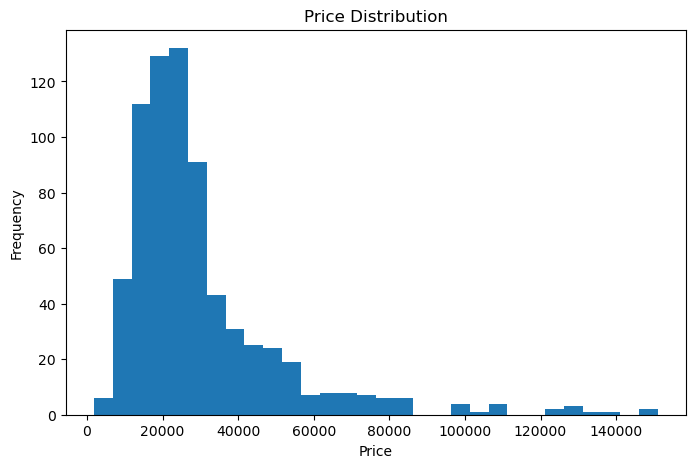

In [32]:
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## This bar chart (countplot) visualizes the most common RAM configurations available in the smartphone market.

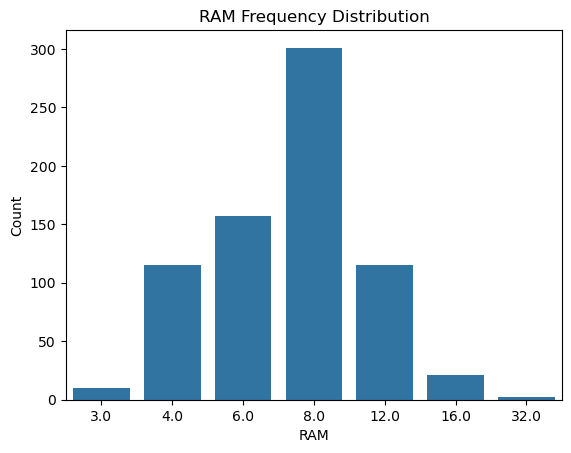

In [33]:
sns.countplot(x=df["RAM (GB)"])
plt.title("RAM Frequency Distribution")
plt.xlabel("RAM")
plt.ylabel("Count")
plt.show()

## This boxplot visualizes the distribution of smartphone prices and helps us spot anomalies.

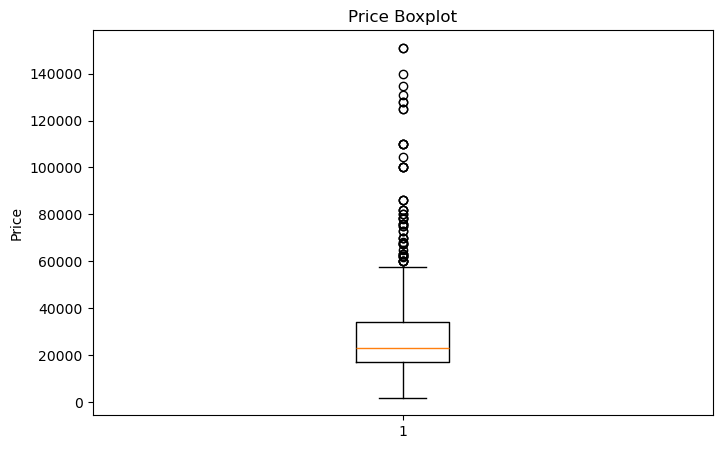

In [34]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Price"])
plt.title("Price Boxplot")
plt.ylabel("Price")
plt.show()

# Bivariate

## A scatter plot to observe if more expensive phones tend to receive higher customer ratings.

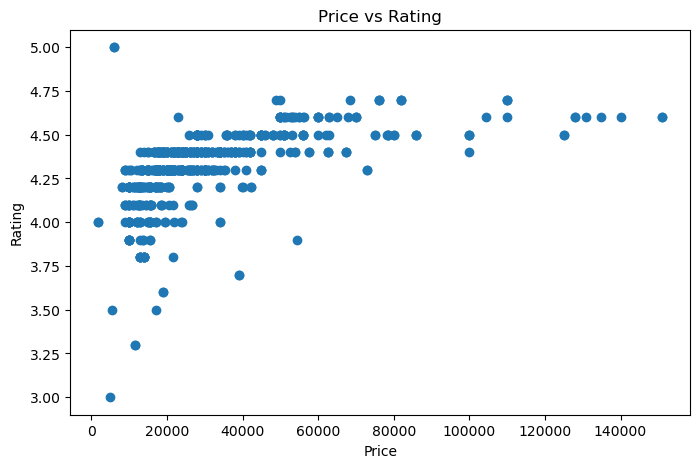

In [35]:
plt.figure(figsize=(8,5))
plt.scatter(df["Price"], df["Rating"])
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

## A boxplot showing how the median price and overall price range increase as the phone's RAM capacity goes up.

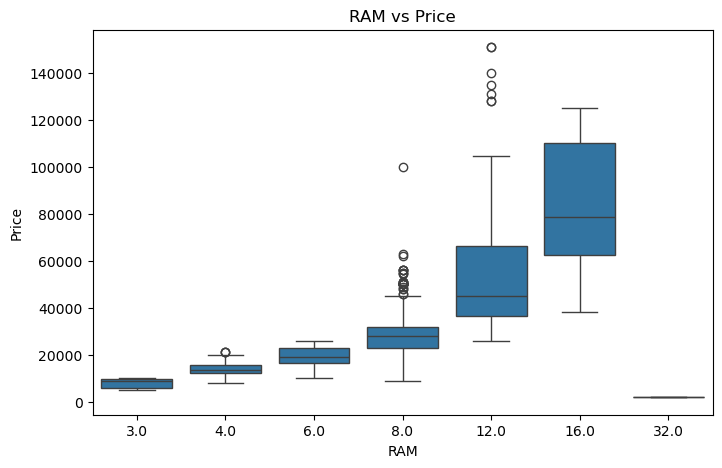

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["RAM (GB)"], y=df["Price"])
plt.title("RAM vs Price")
plt.xlabel("RAM")
plt.ylabel("Price")
plt.show()

## This bar chart shows the relationship between a smartphone's internal storage capacity (ROM) and its average cost.

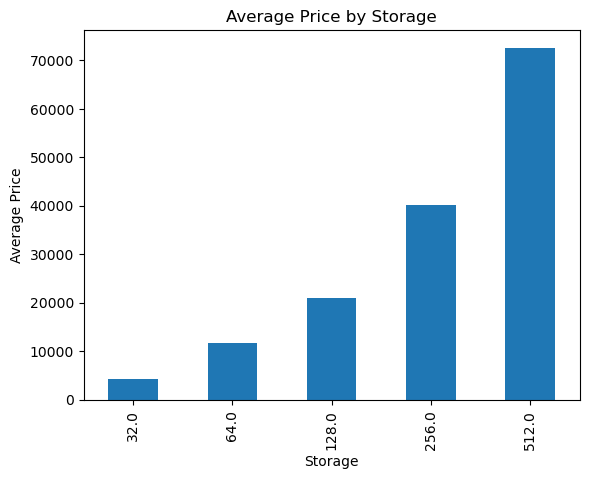

In [37]:
df.groupby("Storage (GB)")["Price"].mean().plot(kind="bar")
plt.title("Average Price by Storage")
plt.xlabel("Storage")
plt.ylabel("Average Price")
plt.show()

# Multi variate

## A bar chart illustrating how the average cost of a smartphone scales with higher RAM capacity.

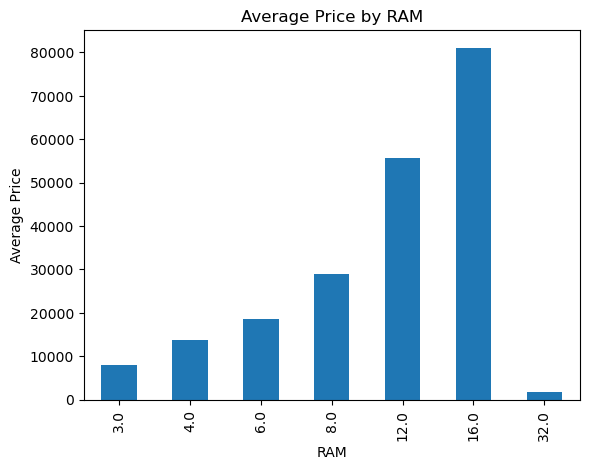

In [38]:
df.groupby("RAM (GB)")["Price"].mean().plot(kind="bar")
plt.title("Average Price by RAM")
plt.xlabel("RAM")
plt.ylabel("Average Price")
plt.show()

## A visual matrix highlighting the strongest relationships between numerical features, such as the high positive correlation between Storage and Price.

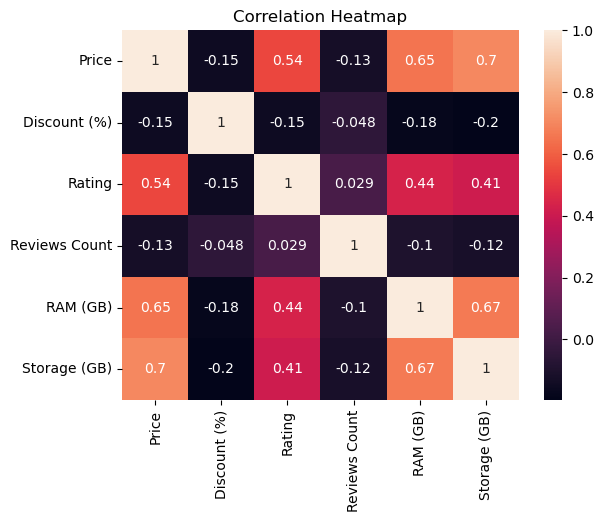

In [39]:
sns.heatmap(df[["Price","Discount (%)","Rating","Reviews Count","RAM (GB)","Storage (GB)"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Conclusion
1. RAM and Storage significantly impact smartphone pricing.
2. Discounts do not always lead to better ratings.
3. Mid-range smartphones dominate the market.
4. Customer engagement depends on pricing, specifications, and perceived value.

In [296]:
print(df["RAM (GB)"].max())


46875.0


In [11]:
# Look at all phones with an impossible amount of RAM (e.g., over 32GB)
outliers = df[df["RAM (GB)"] > 32]
outliers

,Product Name,Price,Original Price,Rating,Brand,Ratings Count,Processor,Reviews Count,RAM (GB),Storage (GB),Discount (%),Screen Size (cm),Battery (mAh)
189,Nokia 2660 Flip 4G Volte Dual SIM keypad Phone...,4999,5899,4.2,Nokia,2027,NaN,111,46875.0,125.0,15.0,7.11,1450.0
682,"Nokia 2660 Flip 4G Dual SIM keypad Phone, Dual...",5899,1499,4.2,Nokia,2107,NaN,134,46875.0,125.0,20.0,7.11,1450.0


In [12]:
# Keep only the rows where RAM is a realistic number (e.g., 32GB or less)
df_cleaned = df[df["RAM (GB)"] <= 32]

In [16]:
# Keeps only the valid rows and overwrites the old dataset
df = df[df["RAM (GB)"] <= 32]

# Now, printing df will show the updated, clean data
df

,Product Name,Price,Original Price,Rating,Brand,Ratings Count,Processor,Reviews Count,RAM (GB),Storage (GB),Discount (%),Screen Size (cm),Battery (mAh)
0,"vivo T5x 5G (Cyber Green, 128 GB)",22999,28999,4.4,vivo,5072,Dimensity 7400-Turbo,344,6.0,128.0,20.0,17.17,7200.0
1,"Ai+ Pulse 2 (Blue, 64 GB)",8999,10999,4.3,Ai,1512,T7250,98,4.0,64.0,18.0,17.13,6000.0
2,"IQOO Z11x 5G (Prismatic Green, 128 GB)",21645,28999,4.4,IQOO,384,NaN,31,6.0,128.0,25.0,17.02,7200.0
3,"Ai+ Pulse 2 (Green, 64 GB)",8999,10999,4.3,Ai,1512,T7250,98,4.0,64.0,18.0,17.13,6000.0
4,"IQOO Z11x 5G (Titan Black, 128 GB)",21972,28999,4.4,IQOO,384,NaN,31,6.0,128.0,24.0,17.02,7200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,"Samsung Galaxy S24 FE 5G (Blue, 128 GB)",39999,59999,4.5,Samsung,78184,Exynos 2400e,5470,8.0,128.0,33.0,17.02,4700.0
976,"Samsung Galaxy S24 FE 5G (Graphite, 256 GB)",45999,65999,4.5,Samsung,78184,Exynos 2400e,5470,8.0,256.0,30.0,17.02,4700.0
977,"LAVA Play Ultra 5G (Arctic Slate, 128 GB)",16999,17999,3.5,LAVA,24,NaN,5,6.0,128.0,5.0,17.02,5000.0
978,"realme Narzo 80 Pro 5G (Speed Silver, 256 GB)",25800,27999,4.5,realme,182,NaN,20,12.0,256.0,7.0,17.20,6000.0


In [17]:
print(df["RAM (GB)"].max())


32.0


In [25]:
# Replace all 0.0 values in the Storage column with 128.0
df["Storage (GB)"] = df["Storage (GB)"].replace(0.0, 128.0)

In [29]:
df["Storage (GB)"].min()

32.0

In [30]:
# Fix the error: If Price > Original Price, make Original Price equal to Price
df.loc[df['Price'] > df['Original Price'], 'Original Price'] = df['Price']

In [31]:
df

,Product Name,Price,Original Price,Rating,Brand,Ratings Count,Processor,Reviews Count,RAM (GB),Storage (GB),Discount (%),Screen Size (cm),Battery (mAh)
0,"vivo T5x 5G (Cyber Green, 128 GB)",22999,28999,4.4,vivo,5072,Dimensity 7400-Turbo,344,6.0,128.0,20.0,17.17,7200.0
1,"Ai+ Pulse 2 (Blue, 64 GB)",8999,10999,4.3,Ai,1512,T7250,98,4.0,64.0,18.0,17.13,6000.0
2,"IQOO Z11x 5G (Prismatic Green, 128 GB)",21645,28999,4.4,IQOO,384,NaN,31,6.0,128.0,25.0,17.02,7200.0
3,"Ai+ Pulse 2 (Green, 64 GB)",8999,10999,4.3,Ai,1512,T7250,98,4.0,64.0,18.0,17.13,6000.0
4,"IQOO Z11x 5G (Titan Black, 128 GB)",21972,28999,4.4,IQOO,384,NaN,31,6.0,128.0,24.0,17.02,7200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,"Samsung Galaxy S24 FE 5G (Blue, 128 GB)",39999,59999,4.5,Samsung,78184,Exynos 2400e,5470,8.0,128.0,33.0,17.02,4700.0
976,"Samsung Galaxy S24 FE 5G (Graphite, 256 GB)",45999,65999,4.5,Samsung,78184,Exynos 2400e,5470,8.0,256.0,30.0,17.02,4700.0
977,"LAVA Play Ultra 5G (Arctic Slate, 128 GB)",16999,17999,3.5,LAVA,24,NaN,5,6.0,128.0,5.0,17.02,5000.0
978,"realme Narzo 80 Pro 5G (Speed Silver, 256 GB)",25800,27999,4.5,realme,182,NaN,20,12.0,256.0,7.0,17.20,6000.0
